# Model Evaluation Visualizations

Notebook này tạo 3 biểu đồ dùng cho phần **Marketing Attribution & Regression Benchmark**:

1. **Grouped Bar Chart**: so sánh `% Credit Share` giữa First-Touch, Last-Touch, Linear và Regression Adjusted Share.
2. **Spearman Rank Correlation Heatmap**: kiểm định mô hình heuristic nào gần với Regression benchmark nhất.
3. **Journey Length Line Chart**: chứng minh `N_Touchpoints` ảnh hưởng mạnh đến conversion rate.

> Gợi ý lưu file này trong repo tại: `model/visualization/model_evaluation_visualizations.ipynb`.


In [1]:
# ============================================================
# 0. Setup
# ============================================================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


def detect_project_root():
    """Detect a reasonable project root for local GitHub usage and this sandbox."""
    cwd = Path.cwd().resolve()
    candidates = [cwd] + list(cwd.parents)[:5]
    folder_markers = [".git", "data_preparation", "model"]
    file_markers = ["data_journeys.csv", "data_touchpoints.csv", "attribution_channel_summary.csv"]

    for candidate in candidates:
        # Avoid choosing system root or broad mount folders as the project root.
        if str(candidate) in {candidate.anchor, "/mnt"}:
            continue
        if any((candidate / marker).exists() for marker in folder_markers + file_markers):
            return candidate

    sandbox_root = Path("/mnt/data")
    if sandbox_root.exists():
        return sandbox_root

    return cwd


PROJECT_ROOT = detect_project_root()

# Output folder for charts and summary CSVs.
OUTPUT_DIR = PROJECT_ROOT / "model" / "visualization" / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figure output folder:", FIG_DIR)


Project root: /mnt/data
Figure output folder: /mnt/data/model/visualization/outputs/figures


## 1. Utility functions and source data

Notebook này ưu tiên đọc output thật từ project nếu có. Nếu chưa tìm thấy file output trong repo, notebook sẽ dùng các giá trị fallback đã được xác nhận từ kết quả model trước đó.


In [2]:
# ============================================================
# 1. Utility functions
# ============================================================
CHANNEL_ORDER = [
    "Display Ads", "Email", "Social Media",
    "Direct Traffic", "Referral", "Search Ads"
]

MODEL_ORDER = ["First-Touch", "Last-Touch", "Linear", "Regression"]

# Fallback values are percentages, not fractions.
# They match the outputs generated from the attribution models and channel_plus_length model.
FALLBACK_SHARE_DATA = pd.DataFrame({
    "Channel": CHANNEL_ORDER,
    "First-Touch": [17.98, 15.71, 16.34, 17.26, 17.14, 15.58],
    "Last-Touch": [16.84, 16.51, 16.09, 17.85, 16.13, 16.59],
    "Linear": [17.10, 16.28, 16.70, 17.15, 16.75, 16.02],
    "Regression": [21.99, 17.84, 16.40, 15.62, 15.47, 12.68],
})

# Fallback values for chart 3, computed from data_journeys.csv in the processed dataset.
FALLBACK_LENGTH_DATA = pd.DataFrame({
    "Touchpoint_Group": ["1", "2", "3", "4", "5+"],
    "Users": [343, 584, 595, 563, 762],
    "Converted_Users": [177, 431, 505, 524, 744],
    "Conversion_Rate": [51.60, 73.80, 84.87, 93.07, 97.64],
})


def find_first_existing(relative_paths):
    """Return the first existing path from a list of relative or absolute paths."""
    search_roots = [PROJECT_ROOT, PROJECT_ROOT.parent]
    sandbox_root = Path("/mnt/data")
    if sandbox_root.exists():
        search_roots.append(sandbox_root)

    for raw_path in relative_paths:
        p = Path(raw_path)
        if p.is_absolute() and p.exists():
            return p
        for root in search_roots:
            candidate = root / p
            if candidate.exists():
                return candidate
    return None


def share_to_percent(series):
    """Convert share column to percentage if it appears to be stored as a fraction."""
    s = pd.to_numeric(series, errors="coerce")
    if s.dropna().max() <= 1.5:
        s = s * 100
    return s


def find_col(df, candidates):
    """Find a column by trying exact candidates and normalized candidates."""
    cols = list(df.columns)
    normalized = {c.lower().replace(" ", "_").replace("-", "_"): c for c in cols}
    for cand in candidates:
        if cand in df.columns:
            return cand
        key = cand.lower().replace(" ", "_").replace("-", "_")
        if key in normalized:
            return normalized[key]
    return None


In [3]:
# ============================================================
# 2. Load / build share table for Chart 1 and Chart 2
# ============================================================

def load_share_table():
    """Load First/Last/Linear shares and Regression adjusted share.

    Preferred source files:
    - model/attribution/outputs/attribution_channel_summary.csv
    - model/channel_plus_length/outputs/channel_plus_length_adjusted_channel_share.csv

    If the files are not found, fallback values are used.
    """
    share_df = FALLBACK_SHARE_DATA.copy()
    source_notes = []

    attribution_path = find_first_existing([
        "model/attribution/outputs/attribution_channel_summary.csv",
        "model/attribution/output/attribution_channel_summary.csv",
        "model/attribution/attribution_channel_summary.csv",
        "outputs/attribution/attribution_channel_summary.csv",
        "attribution_channel_summary.csv",
    ])

    if attribution_path is not None:
        attr = pd.read_csv(attribution_path)
        required_cols = ["Channel", "First_Touch_Share", "Last_Touch_Share", "Linear_Share"]
        if all(c in attr.columns for c in required_cols):
            temp = attr[required_cols].copy()
            temp = temp.rename(columns={
                "First_Touch_Share": "First-Touch",
                "Last_Touch_Share": "Last-Touch",
                "Linear_Share": "Linear",
            })
            for col in ["First-Touch", "Last-Touch", "Linear"]:
                temp[col] = share_to_percent(temp[col])
            share_df = share_df.drop(columns=["First-Touch", "Last-Touch", "Linear"]).merge(
                temp, on="Channel", how="left"
            )
            source_notes.append(f"Loaded attribution shares from: {attribution_path}")

    regression_path = find_first_existing([
        "model/channel_plus_length/outputs/channel_plus_length_adjusted_channel_share.csv",
        "model/channel_plus_length/output/channel_plus_length_adjusted_channel_share.csv",
        "outputs/regression/channel_plus_length/channel_plus_length_adjusted_channel_share.csv",
        "channel_plus_length_adjusted_channel_share.csv",
        "02_adjusted_channel_share.csv",
    ])

    if regression_path is not None:
        reg = pd.read_csv(regression_path)
        channel_col = find_col(reg, ["Channel", "channel"])
        share_col = find_col(reg, [
            "Logistic_Adjusted_Share", "Logistic-adjusted share", "Adjusted_Share",
            "Regression", "Share", "share", "channel_share"
        ])
        if channel_col and share_col:
            temp = reg[[channel_col, share_col]].copy()
            temp.columns = ["Channel", "Regression"]
            temp["Regression"] = share_to_percent(temp["Regression"])
            share_df = share_df.drop(columns=["Regression"]).merge(temp, on="Channel", how="left")
            source_notes.append(f"Loaded regression adjusted shares from: {regression_path}")

    share_df["Channel"] = pd.Categorical(share_df["Channel"], categories=CHANNEL_ORDER, ordered=True)
    share_df = share_df.sort_values("Channel").reset_index(drop=True)

    fallback = FALLBACK_SHARE_DATA.set_index("Channel")
    for col in MODEL_ORDER:
        share_df[col] = share_df.apply(
            lambda row: fallback.loc[str(row["Channel"]), col] if pd.isna(row[col]) else row[col],
            axis=1,
        )

    return share_df, source_notes

share_df, source_notes = load_share_table()

print("Source notes:")
for note in source_notes or ["Using fallback values embedded in notebook."]:
    print("-", note)

display(share_df)
share_df.to_csv(TABLE_DIR / "chart_1_2_model_credit_share.csv", index=False)


Source notes:
- Loaded attribution shares from: /mnt/data/attribution_channel_summary.csv


,Channel,Regression,First-Touch,Last-Touch,Linear
0,Display Ads,21.99,17.975640,16.841663,17.100217
1,Email,17.84,15.707686,16.505670,16.283779
2,Social Media,16.40,16.337673,16.085678,16.699022
3,Direct Traffic,15.62,17.261655,17.849643,17.147272
4,Referral,15.47,17.135657,16.127677,16.745273
5,Search Ads,12.68,15.581688,16.589668,16.024437


## 2. Biểu đồ 1 — Grouped Bar Chart

**Tên slide:** So sánh Tỷ lệ Phân bổ Công trạng (% Credit Share) giữa các Mô hình.

Biểu đồ này so sánh 4 cách nhìn về phân bổ credit:

- **First-Touch**: ưu tiên kênh mở đầu journey.
- **Last-Touch**: ưu tiên kênh cuối trước conversion.
- **Linear**: chia đều credit cho toàn bộ journey.
- **Regression Adjusted Share**: benchmark thống kê từ model `channel_plus_length`.


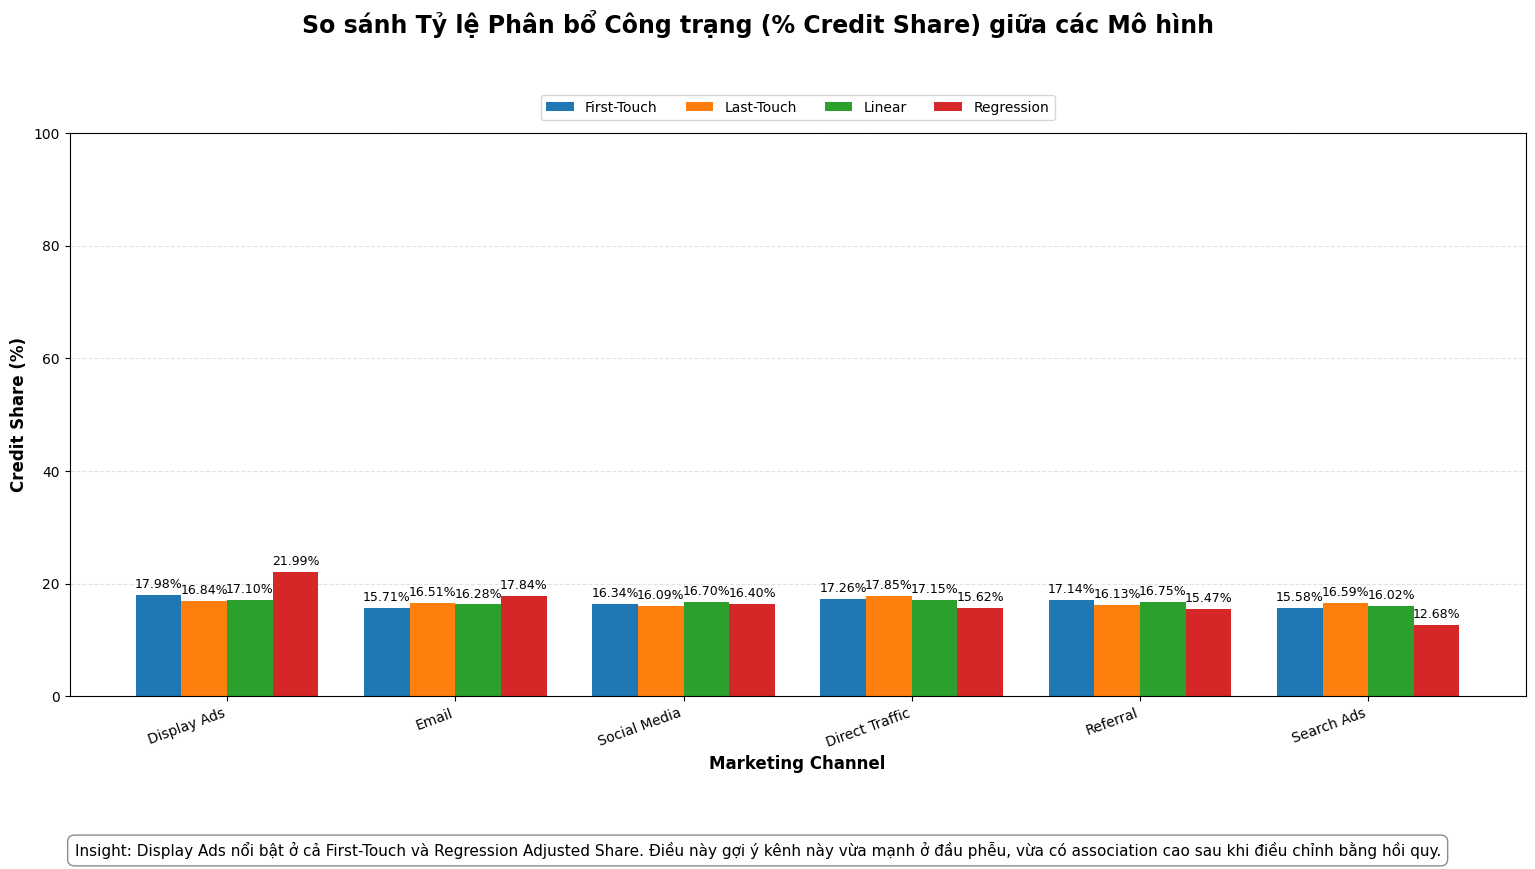

Saved: /mnt/data/model/visualization/outputs/figures/chart_1_grouped_credit_share.png


In [4]:
# ============================================================
# Chart 1: Grouped Bar Chart
# ============================================================
# The user requested a 0–100% y-axis. This is set to 100 by default.
# If you want the slide to emphasize small differences more clearly, change it to 25.
GROUPED_BAR_Y_MAX = 100

x = np.arange(len(share_df["Channel"]))
width = 0.20

fig, ax = plt.subplots(figsize=(16, 8.8))

for i, model_name in enumerate(MODEL_ORDER):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, share_df[model_name], width, label=model_name)
    ax.bar_label(bars, labels=[f"{v:.2f}%" for v in share_df[model_name]], padding=3, fontsize=9)

fig.suptitle(
    "So sánh Tỷ lệ Phân bổ Công trạng (% Credit Share) giữa các Mô hình",
    fontsize=17,
    fontweight="bold",
    y=0.98,
)
ax.set_xlabel("Marketing Channel", fontsize=12, fontweight="bold")
ax.set_ylabel("Credit Share (%)", fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(share_df["Channel"], rotation=20, ha="right")
ax.set_ylim(0, GROUPED_BAR_Y_MAX)
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.08), frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

insight = (
    "Insight: Display Ads nổi bật ở cả First-Touch và Regression Adjusted Share. "
    "Điều này gợi ý kênh này vừa mạnh ở đầu phễu, vừa có association cao sau khi điều chỉnh bằng hồi quy."
)
fig.text(
    0.5, 0.015, insight,
    ha="center", va="bottom", fontsize=11,
    bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor="gray", alpha=0.9),
)

fig.subplots_adjust(left=0.07, right=0.98, top=0.84, bottom=0.20)
chart1_path = FIG_DIR / "chart_1_grouped_credit_share.png"
fig.savefig(chart1_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", chart1_path)


## 3. Biểu đồ 2 — Spearman Rank Correlation Heatmap

**Tên slide:** Kiểm định độ hợp lý của các Mô hình Phân bổ quy tắc.

Heatmap này chỉ có 4 hàng và 4 cột, tương ứng với 4 mô hình: First-Touch, Last-Touch, Linear, Regression.

Giá trị càng gần **1.0** nghĩa là thứ hạng channel của hai mô hình càng giống nhau. Ở đây, Regression được xem là benchmark thống kê để đánh giá các heuristic attribution model.


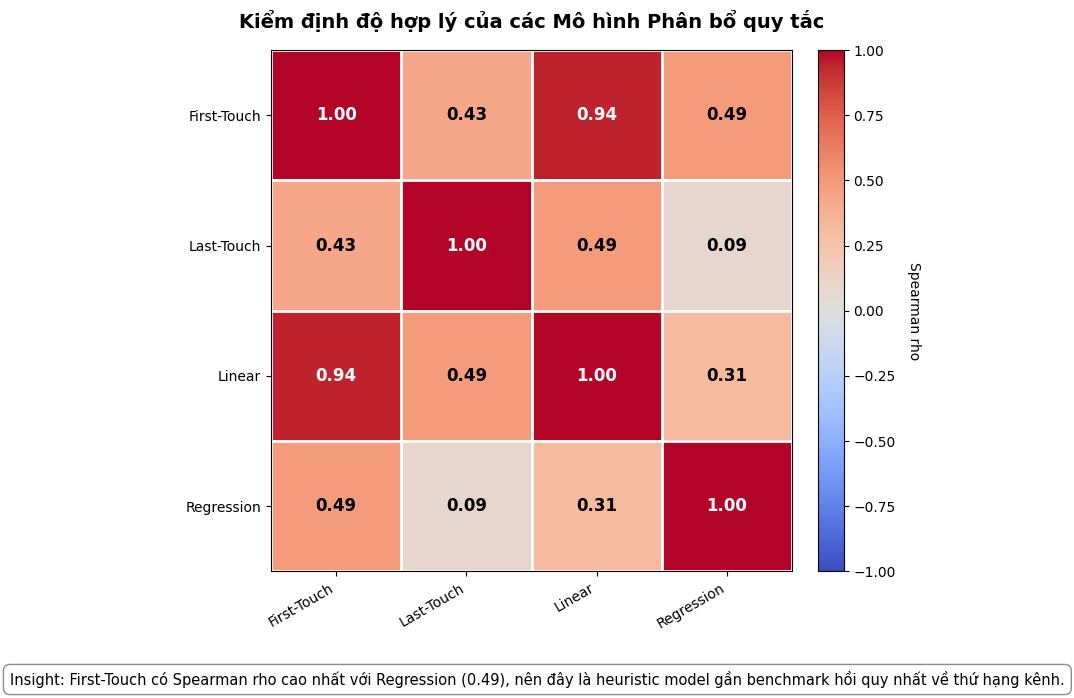

Saved: /mnt/data/model/visualization/outputs/figures/chart_2_spearman_heatmap.png


,First-Touch,Last-Touch,Linear,Regression
First-Touch,1.000000,0.428571,0.942857,0.485714
Last-Touch,0.428571,1.000000,0.485714,0.085714
Linear,0.942857,0.485714,1.000000,0.314286
Regression,0.485714,0.085714,0.314286,1.000000


In [5]:
# ============================================================
# Chart 2: Spearman Rank Correlation Heatmap
# ============================================================
score_matrix = share_df.set_index("Channel")[MODEL_ORDER]
spearman_corr = score_matrix.corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(spearman_corr.values, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_title(
    "Kiểm định độ hợp lý của các Mô hình Phân bổ quy tắc",
    fontsize=14,
    fontweight="bold",
    pad=16,
)
ax.set_xticks(np.arange(len(MODEL_ORDER)))
ax.set_yticks(np.arange(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER, rotation=30, ha="right")
ax.set_yticklabels(MODEL_ORDER)

for i in range(len(MODEL_ORDER)):
    for j in range(len(MODEL_ORDER)):
        value = spearman_corr.iloc[i, j]
        text_color = "white" if abs(value) >= 0.65 else "black"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=12, fontweight="bold")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Spearman rho", rotation=270, labelpad=18)

ax.set_xticks(np.arange(-0.5, len(MODEL_ORDER), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(MODEL_ORDER), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

best_heuristic = spearman_corr.loc[["First-Touch", "Last-Touch", "Linear"], "Regression"].idxmax()
best_value = spearman_corr.loc[best_heuristic, "Regression"]
insight = (
    f"Insight: {best_heuristic} có Spearman rho cao nhất với Regression ({best_value:.2f}), "
    "nên đây là heuristic model gần benchmark hồi quy nhất về thứ hạng kênh."
)
fig.text(
    0.5, 0.01, insight,
    ha="center", va="bottom", fontsize=10.5,
    bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor="gray", alpha=0.9),
)

fig.tight_layout(rect=[0, 0.07, 1, 1])
chart2_path = FIG_DIR / "chart_2_spearman_heatmap.png"
fig.savefig(chart2_path, dpi=300, bbox_inches="tight")
plt.show()

spearman_corr.to_csv(TABLE_DIR / "chart_2_spearman_rank_correlation.csv")
print("Saved:", chart2_path)
display(spearman_corr)


## 4. Biểu đồ 3 — Journey Length Line Chart

**Tên slide:** Tác động của Độ dài Hành trình (`N_Touchpoints`) đến Tỷ lệ Chuyển đổi.

Biểu đồ này chứng minh vì sao cần model `journey_length_only` và `channel_plus_length`: nếu số lượng touchpoints ảnh hưởng mạnh đến conversion, ta phải kiểm soát biến này khi đánh giá channel attribution.


In [6]:
# ============================================================
# Chart 3 data: Conversion rate by N_Touchpoints
# ============================================================
def normalize_binary(series):
    """Convert common binary formats to 0/1 integers."""
    if series.dtype == bool:
        return series.astype(int)

    s = series.copy()
    if pd.api.types.is_numeric_dtype(s):
        return (pd.to_numeric(s, errors="coerce").fillna(0) > 0).astype(int)

    mapping = {
        "true": 1, "false": 0,
        "yes": 1, "no": 0,
        "y": 1, "n": 0,
        "1": 1, "0": 0,
        "converted": 1, "not converted": 0,
    }
    return s.astype(str).str.strip().str.lower().map(mapping).fillna(0).astype(int)


def load_journey_length_summary():
    journey_path = find_first_existing([
        "data_preparation/outputs/data_journeys.csv",
        "data/data_journeys.csv",
        "outputs/data_journeys.csv",
        "data_journeys.csv",
    ])

    if journey_path is None:
        print("Journey file not found. Using fallback journey-length summary values.")
        return FALLBACK_LENGTH_DATA.copy(), None

    journeys = pd.read_csv(journey_path)
    length_col = find_col(journeys, ["N_Touchpoints", "n_touchpoints", "touchpoints", "journey_length"])
    target_col = find_col(journeys, ["Converted", "User_Converted", "conversion", "is_conversion"])
    user_col = find_col(journeys, ["User ID", "User_ID", "user_id", "userid"])

    if length_col is None or target_col is None:
        print("Required columns not found. Using fallback journey-length summary values.")
        print("Available columns:", list(journeys.columns))
        return FALLBACK_LENGTH_DATA.copy(), journey_path

    temp = journeys.copy()
    temp["N_Touchpoints_Clean"] = pd.to_numeric(temp[length_col], errors="coerce")
    temp["Converted_Clean"] = normalize_binary(temp[target_col])
    temp = temp.dropna(subset=["N_Touchpoints_Clean"])

    temp["Touchpoint_Group"] = np.where(
        temp["N_Touchpoints_Clean"] >= 5,
        "5+",
        temp["N_Touchpoints_Clean"].astype(int).astype(str),
    )
    order = ["1", "2", "3", "4", "5+"]
    temp["Touchpoint_Group"] = pd.Categorical(temp["Touchpoint_Group"], categories=order, ordered=True)

    count_col = user_col if user_col is not None else target_col
    summary = (
        temp.groupby("Touchpoint_Group", observed=False)
        .agg(
            Users=(count_col, "count"),
            Converted_Users=("Converted_Clean", "sum"),
            Conversion_Rate=("Converted_Clean", "mean"),
        )
        .reset_index()
    )
    summary["Conversion_Rate"] = summary["Conversion_Rate"] * 100
    summary = summary.dropna(subset=["Touchpoint_Group"])
    return summary, journey_path

length_df, journey_source = load_journey_length_summary()
print("Journey source:", journey_source if journey_source else "Fallback values")
display(length_df)
length_df.to_csv(TABLE_DIR / "chart_3_conversion_rate_by_touchpoints.csv", index=False)


Journey source: /mnt/data/data_journeys.csv


,Touchpoint_Group,Users,Converted_Users,Conversion_Rate
0,1,343,177,51.603499
1,2,584,431,73.801370
2,3,595,505,84.873950
3,4,563,524,93.072824
4,5+,762,744,97.637795


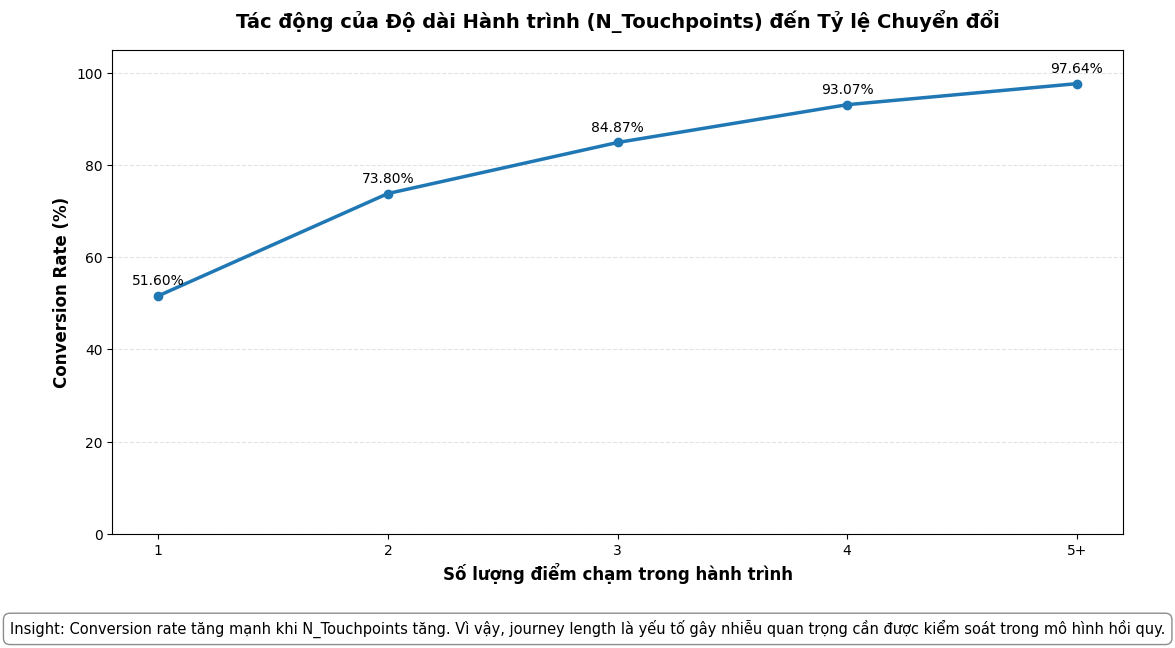

Saved: /mnt/data/model/visualization/outputs/figures/chart_3_conversion_rate_by_touchpoints.png


In [7]:
# ============================================================
# Chart 3: Line Chart
# ============================================================
fig, ax = plt.subplots(figsize=(11, 6.5))

x_labels = length_df["Touchpoint_Group"].astype(str).tolist()
y_values = length_df["Conversion_Rate"].astype(float).tolist()

ax.plot(x_labels, y_values, marker="o", linewidth=2.5)

for x, y in zip(x_labels, y_values):
    ax.annotate(f"{y:.2f}%", xy=(x, y), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=10)

ax.set_title(
    "Tác động của Độ dài Hành trình (N_Touchpoints) đến Tỷ lệ Chuyển đổi",
    fontsize=14,
    fontweight="bold",
    pad=16,
)
ax.set_xlabel("Số lượng điểm chạm trong hành trình", fontsize=12, fontweight="bold")
ax.set_ylabel("Conversion Rate (%)", fontsize=12, fontweight="bold")
ax.set_ylim(0, 105)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

insight = (
    "Insight: Conversion rate tăng mạnh khi N_Touchpoints tăng. "
    "Vì vậy, journey length là yếu tố gây nhiễu quan trọng cần được kiểm soát trong mô hình hồi quy."
)
fig.text(
    0.5, 0.01, insight,
    ha="center", va="bottom", fontsize=10.5,
    bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor="gray", alpha=0.9),
)

fig.tight_layout(rect=[0, 0.07, 1, 1])
chart3_path = FIG_DIR / "chart_3_conversion_rate_by_touchpoints.png"
fig.savefig(chart3_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", chart3_path)


## 5. Suggested GitHub placement

Nên push notebook này lên GitHub vì nó giải thích trực quan kết quả của nhóm model. Vị trí khuyến nghị:

```text
model/
└── visualization/
    ├── model_evaluation_visualizations.ipynb
    └── outputs/
        ├── figures/
        └── tables/
```

Notebook này nên được xem là phần **model interpretation / model evaluation visualization**, không phải phần training model chính.
